<a href="https://colab.research.google.com/github/Atikahdr/ElevvoML-LoanApprovalPrediction/blob/main/LoanApprovalPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Connect G-Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Load Data

In [ ]:
# Load Dataset
loan_data = pd.read_csv('/content/drive/MyDrive/Data Enthusiast Project/Elevvo Internship - ML/LoanApprovalPrediction/loan_approval_dataset.csv')

In [ ]:
# First 5 row of the dataset
loan_data.head(5)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# 4. Data Overview

In [ ]:
# Number of rows and columns
loan_data.shape

(4269, 13)

In [ ]:
# Display Information of Dataset
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
# Summary Statistics
print('Summary Statistics of Numerical')
display(loan_data.describe())

Summary Statistics of Numerical


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
# Check all columns
print(loan_data.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [ ]:
# there is minus data in residential asset value
minus_count = (loan_data[' residential_assets_value'] < 0).sum()
total_data =len(loan_data)

print('Minus data amount:', minus_count)
print('Persentase:', round((minus_count / total_data) * 100, 2), '%')

Minus data amount: 28
Persentase: 0.66 %


In [ ]:
# Summary Statistics
print('Summary Statistics of Categorical')
display(loan_data.describe(include='object').T)

Summary Statistics of Categorical


,count,unique,top,freq
education,4269,2,Graduate,2144
self_employed,4269,2,Yes,2150
loan_status,4269,2,Approved,2656


In [ ]:
# Checking Duplicated
loan_data.duplicated().sum()

np.int64(0)

In [ ]:
# Checking Null Missing Value
loan_data.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [ ]:
loan_data[' education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [ ]:
loan_data[' self_employed'].unique()

array([' No', ' Yes'], dtype=object)

leading whitespace in the columns

# 5. Cleaning Data

In [ ]:
# Remove leading and trailing whitespace
loan_data.columns = loan_data.columns.str.strip()
loan_data['education'] = loan_data['education'].str.strip()
loan_data['self_employed'] = loan_data['self_employed'].str.strip()

In [ ]:
# Drop loan_id and minus data in residential_asset_value
loan_data = loan_data.drop(columns=['loan_id'])
loan_data = loan_data[loan_data['residential_assets_value'] >= 0]

In [ ]:
# Check all columns
print(loan_data.columns.tolist())

['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [ ]:
loan_data['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [ ]:
loan_data['self_employed'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
minus_count = (loan_data['residential_assets_value'] < 0).sum()
total_data =len(loan_data)

print('Minus data amount:', minus_count)

Minus data amount: 0


In [ ]:
loan_data.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
loan_data.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4241.000000,4.241000e+03,4.241000e+03,4241.000000,4241.000000,4.241000e+03,4.241000e+03,4.241000e+03,4.241000e+03
mean,2.497996,5.074251e+06,1.517840e+07,10.902146,599.685687,7.522613e+06,4.985121e+06,1.517121e+07,4.991488e+06
std,1.695599,2.803166e+06,9.034490e+06,5.708988,172.277302,6.495800e+06,4.391504e+06,9.094717e+06,3.249494e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,0.000000e+00,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.400000e+06
50%,3.000000,5.100000e+06,1.460000e+07,10.000000,600.000000,5.700000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,747.000000,1.140000e+07,7.700000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


# 6. Exploratory Data Analysis (EDA)

In [ ]:
# Check Imbalance loan_status
loan_data['loan_status'].value_counts(normalize=True)

,proportion
loan_status,
Approved,0.622495
Rejected,0.377505


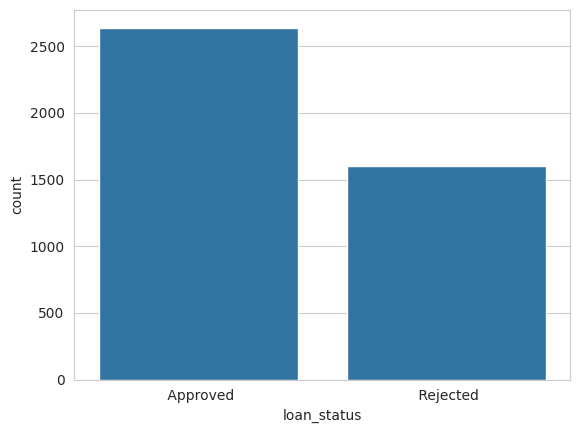

In [ ]:
sns.countplot(x='loan_status', data=loan_data)
plt.show()

In [ ]:
loan_data['loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

📊 Insight Class Distribution – Loan Status

The distribution of loan statuses shows that 62.22% of applications were approved, while 37.78% were rejected. This means that the majority of applicants in the dataset met the loan approval criteria.

This proportion indicates that the approval rate is higher than the rejection rate, but the difference is not significant. This means that the selection process remains selective, and not all applications are immediately accepted.

In [ ]:
# Column Numeric
num_cols = loan_data.select_dtypes(include='int64').columns

# Columns Categorical
cat_cols = loan_data.select_dtypes(include='object').columns

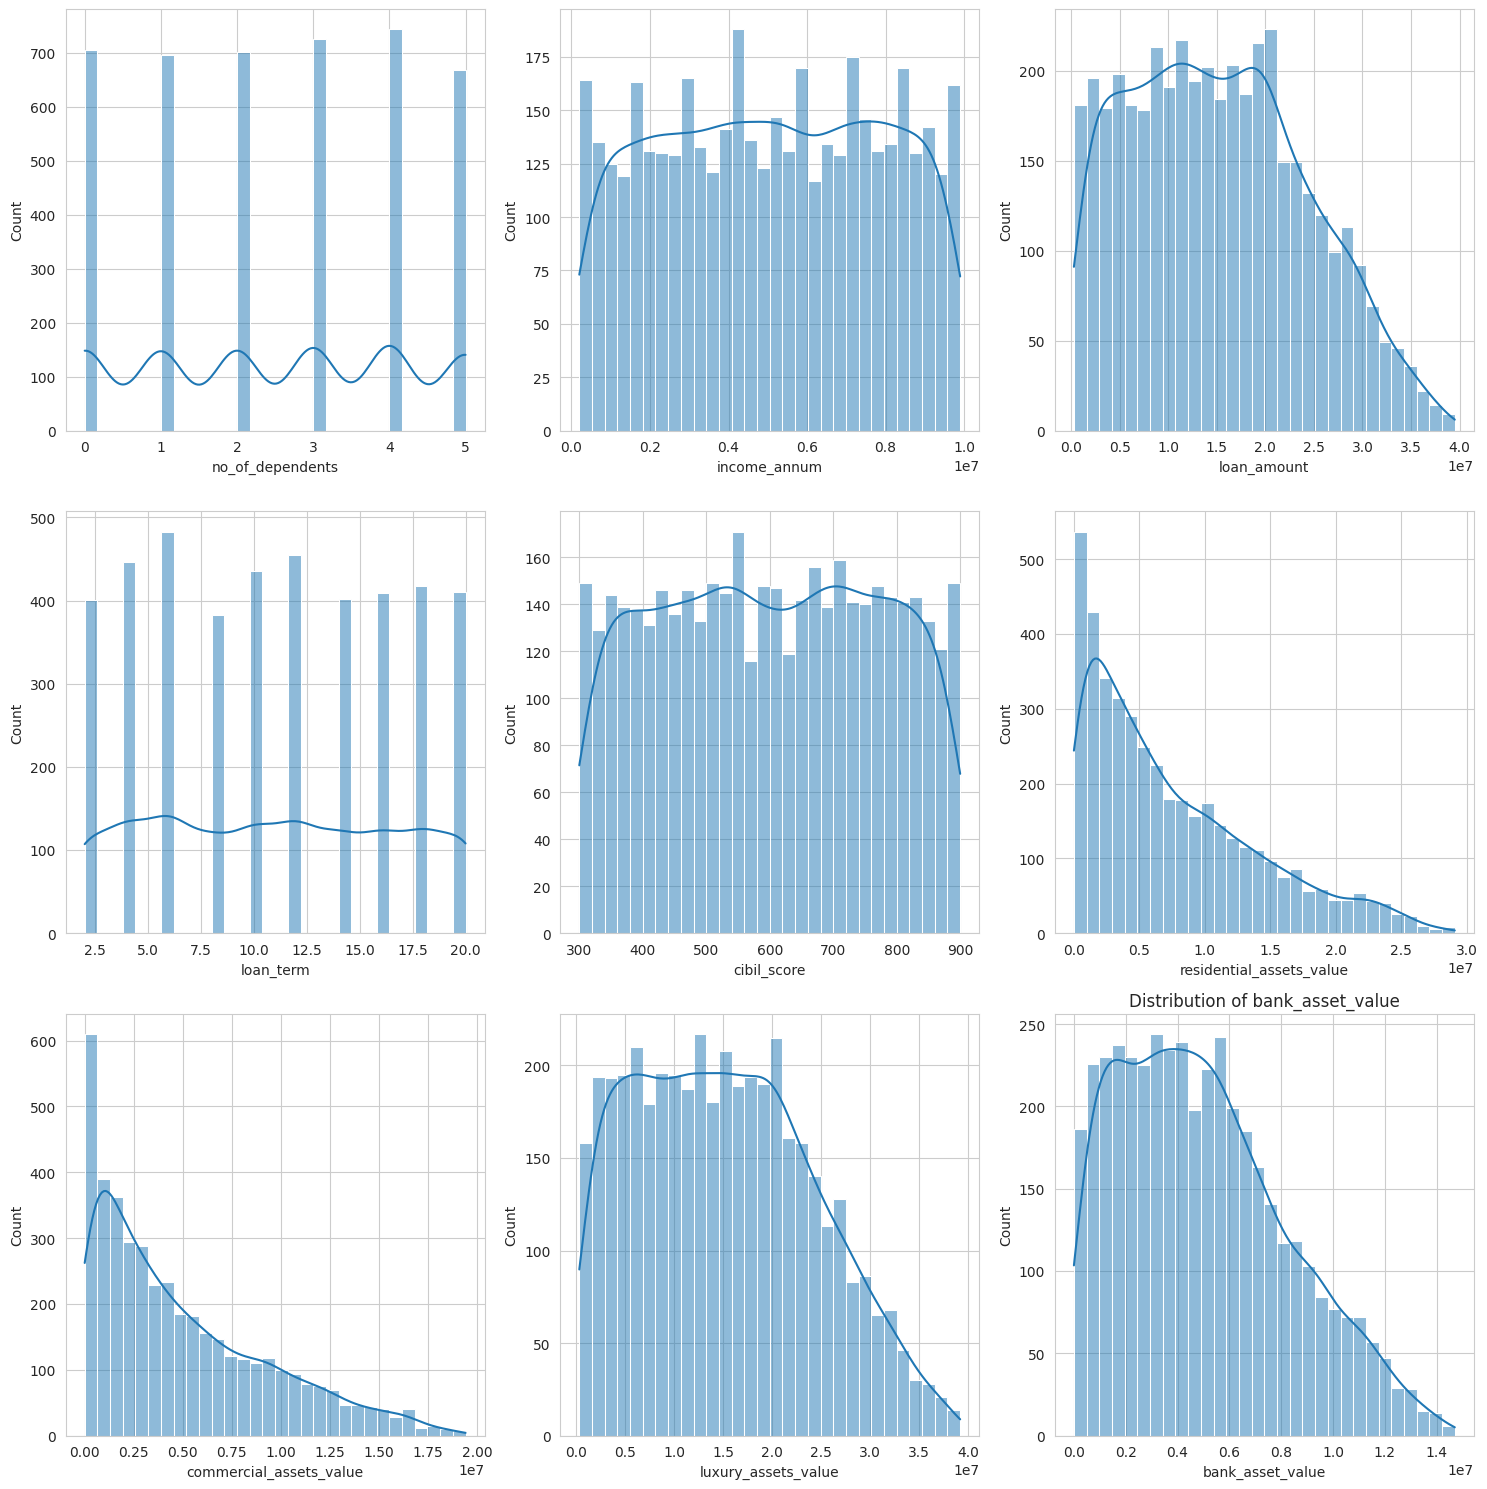

In [ ]:
import math

# Set figure style
sns.set_style('whitegrid')

# Determine grid size
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

# Create Figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

# Plot each Histogram
for i, col in enumerate(num_cols):
    sns.histplot(loan_data[col], bins=30, kde=True, ax=axes[i])
    plt.title(f'Distribution of {col}')

# Remove empety subplot if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Insight**
- Financial features show a right-skewed distribution (normal in wealth data).
-There are no abnormalities or extreme imbalances.
- Credit scores have a wide spread and are the main driver of class separation.
- The dataset is very clean and highly separable.

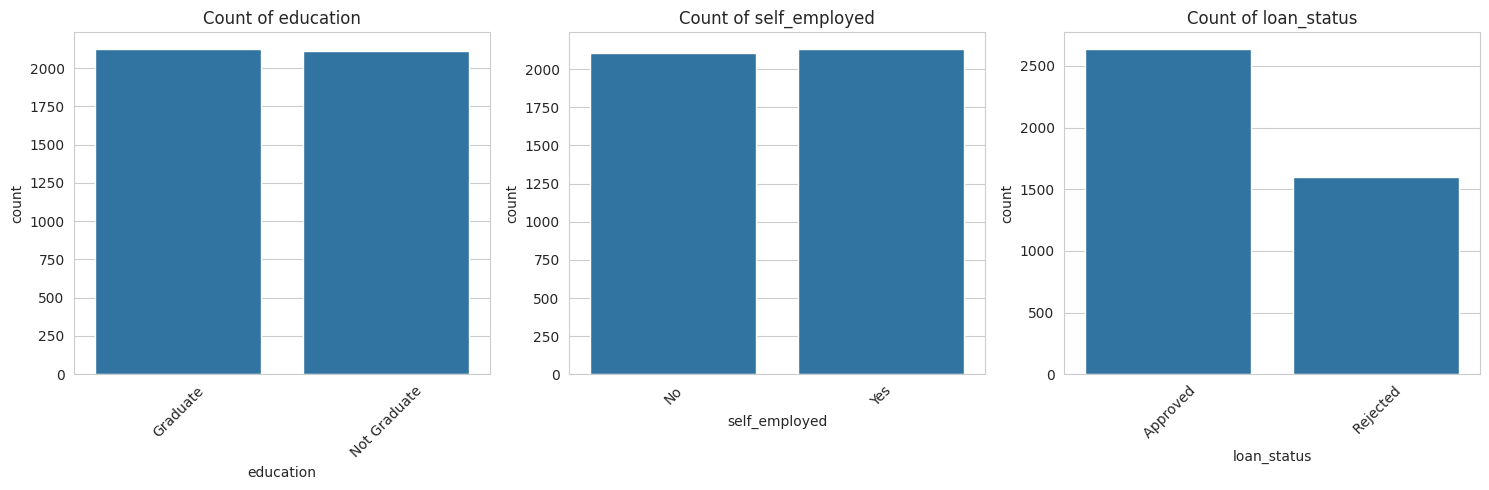

In [ ]:
# Catagorical Columns
cat_cols = loan_data.select_dtypes(include='object').columns

# Set Style
sns.set_style('whitegrid')

# Create Subplots
fig, axes = plt.subplots(1, len(cat_cols), figsize=(15,5))

# If only one categorical columns
if len(cat_cols) == 1:
    axes = [axes]

# Loop
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=loan_data, x=col, ax=ax)
    ax.set_title(f'Count of {col}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

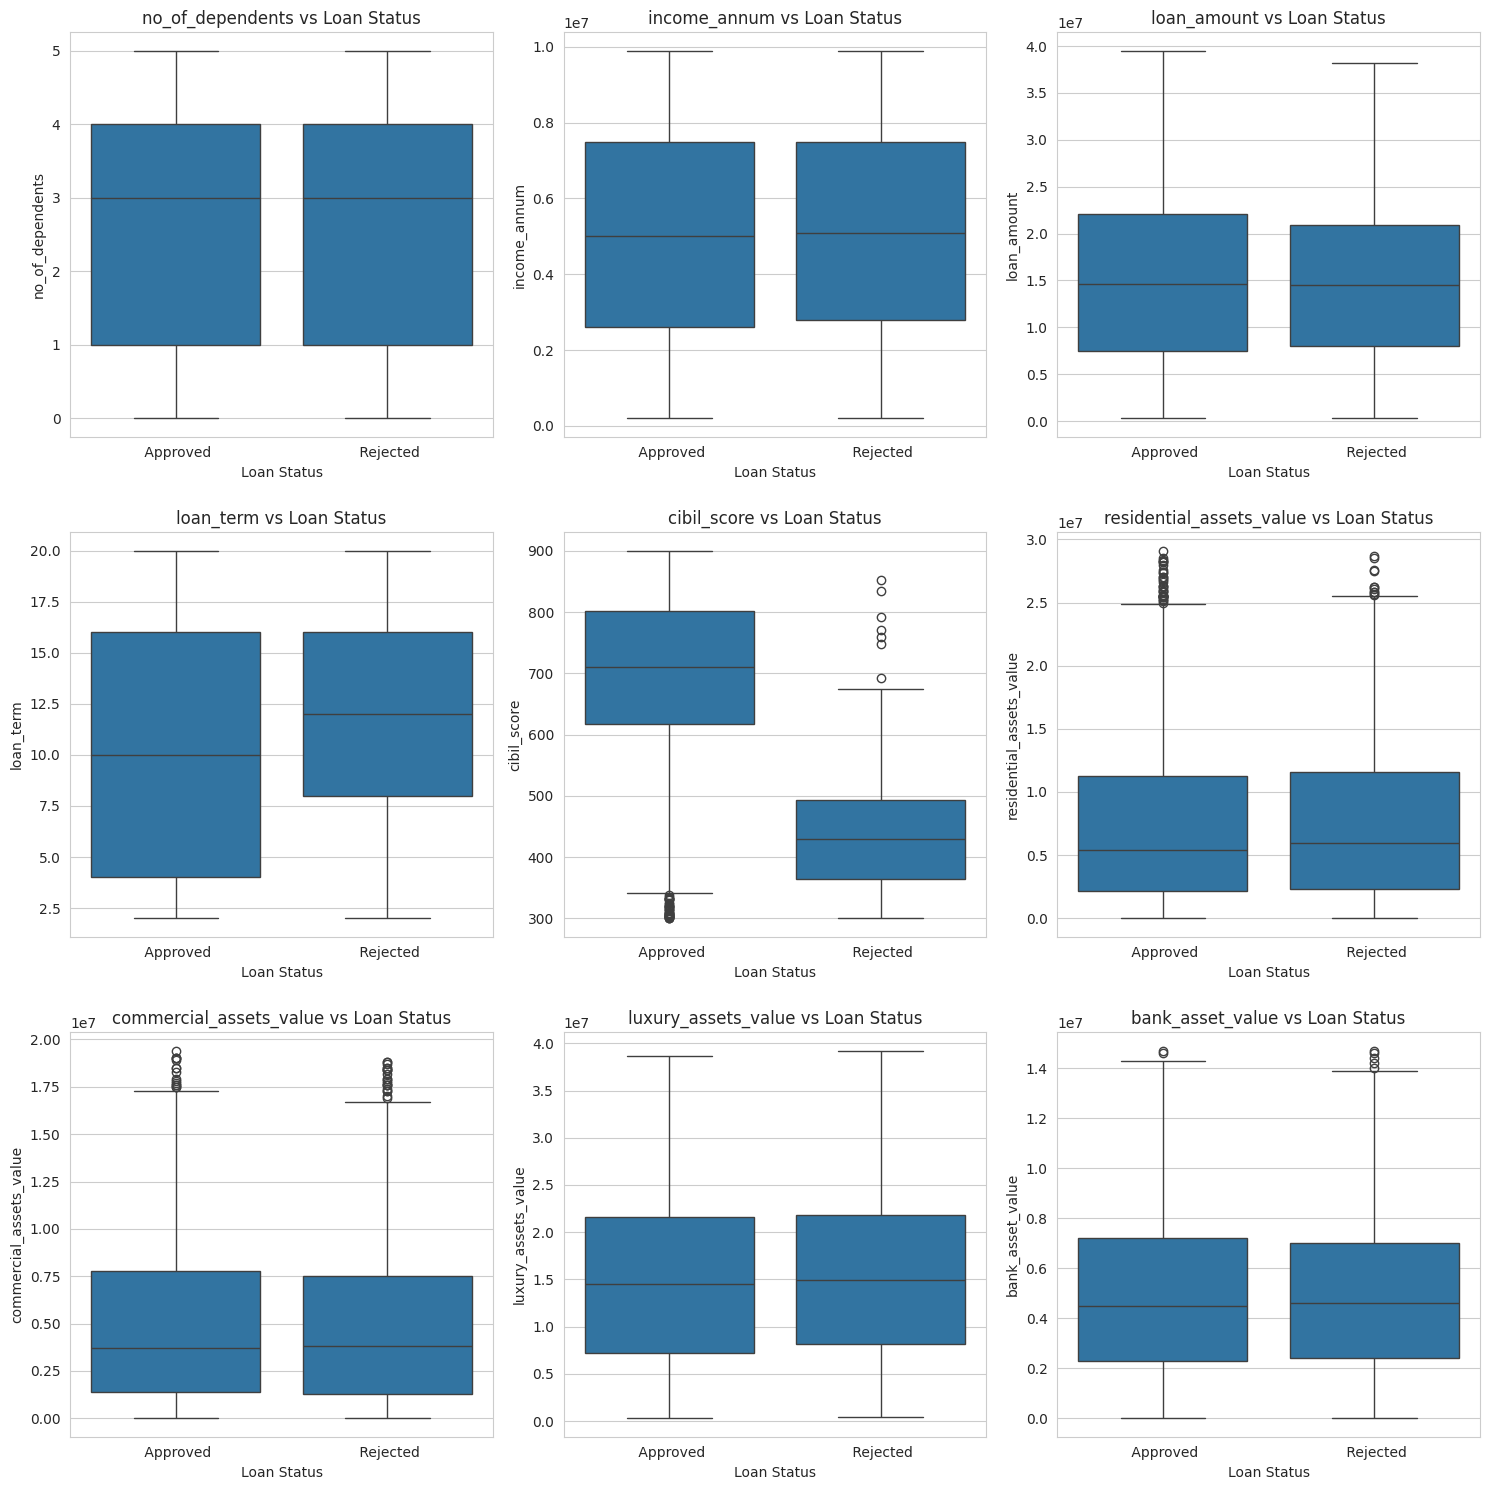

In [ ]:
# Numerical Features vs Loan Status (Boxplot Version)

# Select numerical columns
num_cols = loan_data.select_dtypes(include=['int64', 'float64']).columns

# Remove identifier if exists
plot_cols = [col for col in num_cols if col != 'loan_id']

# Grid layout
n_cols = 3
n_rows = math.ceil(len(plot_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(plot_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(
        data=loan_data,
        x='loan_status',
        y=col
    )

    plt.title(f"{col} vs Loan Status")
    plt.xlabel("Loan Status")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Insight**
- CIBIL scores show a very clear class split.
- Other financial features show nearly identical distributions across classes.
- Approval decisions in the dataset are heavily driven by credit scores.
- The model's high performance is due to its natural separability, not its complexity.


The exploratory analysis shows strong class separation driven almost entirely by credit score. Other financial variables show minimal distribution difference between approved and rejected groups, indicating a highly credit-score-centric approval system.

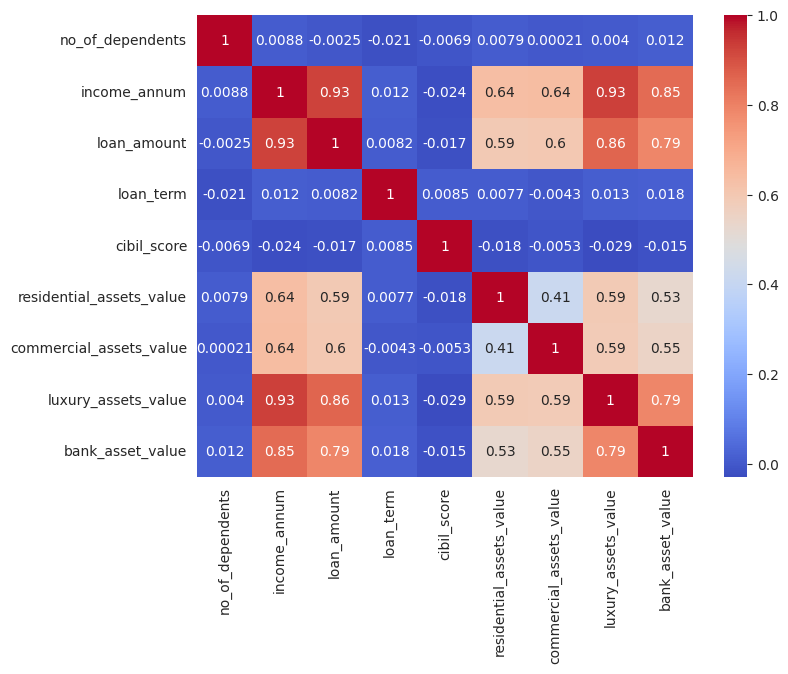

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(loan_data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# 7. Split Dataset

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Split Features and Target

X = loan_data.drop('loan_status', axis=1)
y = loan_data['loan_status']

# Encode Target
le = LabelEncoder()
y = le.fit_transform(y)

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify=y,
    random_state=42
)

## Preprocessor

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X.select_dtypes(include='int64').columns
cat_cols = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

# 8. Syntetic Minority Oversampling Technique (SMOTE) - Imbalance Data

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

#Logistic Regression Model
lr_model = LogisticRegression(
          penalty='l2',
          C=1,
          max_iter=1000,
          class_weight='balanced',
          random_state=42
)

# Fit & predict Logistic Regressiom Model
lr_model.fit(X_train_smote, y_train_smote)
y_pred_lr = lr_model.predict(X_test_processed)
y_prob_lr = lr_model.predict_proba(X_test_processed)[:, 1]

# Model Evaluation
print('Logistic Regression')
print('Accuracy:', round(accuracy_score(y_test, y_pred_lr) * 100, 2))
print('ROC AUC:', round(roc_auc_score(y_test, y_prob_lr) * 100, 2))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred_lr))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_lr))

#Decision Tree Model
dt_model = DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
)

# Fit & predict Decision Tree Model
dt_model.fit(X_train_smote, y_train_smote)
y_pred_dt = dt_model.predict(X_test_processed)
y_prob_dt = dt_model.predict_proba(X_test_processed)[:, 1]

# Model Evaluation
print('\nDecision Tree')
print('Accuracy:', round(accuracy_score(y_test, y_pred_dt) * 100, 2))
print('ROC AUC:', round(roc_auc_score(y_test, y_prob_dt) * 100, 2))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred_dt))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_dt))

Logistic Regression
Accuracy: 92.23
ROC AUC: 97.22

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       528
           1       0.87      0.93      0.90       321

    accuracy                           0.92       849
   macro avg       0.91      0.92      0.92       849
weighted avg       0.92      0.92      0.92       849

Confusion Matrix:
[[484  44]
 [ 22 299]]

Decision Tree
Accuracy: 96.82
ROC AUC: 99.52

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       528
           1       0.93      0.99      0.96       321

    accuracy                           0.97       849
   macro avg       0.96      0.97      0.97       849
weighted avg       0.97      0.97      0.97       849

Confusion Matrix:
[[504  24]
 [  3 318]]


The Decision Tree demonstrated superior performance with an ROC AUC of 99.52% and a Recall of 99% for approved classes. This model was able to reduce rejection errors to just 3 cases, resulting in greater business profitability by minimizing the loss of many eligible applicants.

## Overfitting Check


In [ ]:
#Decision Tree Model
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

# Train Decision Tree Model
dt_model.fit(X_train_processed, y_train)
y_train_pred = dt_model.predict(X_train_processed)
y_train_prob = dt_model.predict_proba(X_train_processed)[:, 1]

train_acc = accuracy_score(y_train, y_train_pred)
train_roc = roc_auc_score(y_train, y_train_prob)

print('Overfitting Check - Decision Tree')
print('\nTrain Set')
print('Accuracy:', round(train_acc * 100, 2), '%')
print('ROC AUC:', round(train_roc * 100, 2), '%')

# Test Set Evaluation
y_test_pred = dt_model.predict(X_test_processed)
y_test_prob = dt_model.predict_proba(X_test_processed)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, y_test_prob)

print('\nTest Set')
print('Accuracy:', round(test_acc * 100, 2), '%')
print('ROC AUC:', round(test_roc * 100, 2), '%')

# GAP
print('\nGAP (Train - Test)')
print('Accuracy GAP:', round((train_acc - test_acc) * 100, 2), '%')
print('ROC AUC GAP:', round((train_roc - test_roc) * 100, 2), '%')

Overfitting Check - Decision Tree

Train Set
Accuracy: 97.49 %
ROC AUC: 99.83 %

Test Set
Accuracy: 96.82 %
ROC AUC: 99.23 %

GAP (Train - Test)
Accuracy GAP: 0.67 %
ROC AUC GAP: 0.6 %


The Decision Tree model shows minimal generalization gap and near-perfect ROC AUC. This indicates strong class separability in the dataset and stable model performance without overfitting.

                      Model  Accuracy  ROC AUC  Precision  Recall  F1 Score  \
0  Logistic Regression (L2)     92.23    97.22      87.17   93.15     90.06   
1             Decision Tree     96.82    99.23      92.98   99.07     95.93   

   F2 Score  
0     91.89  
1     97.79  


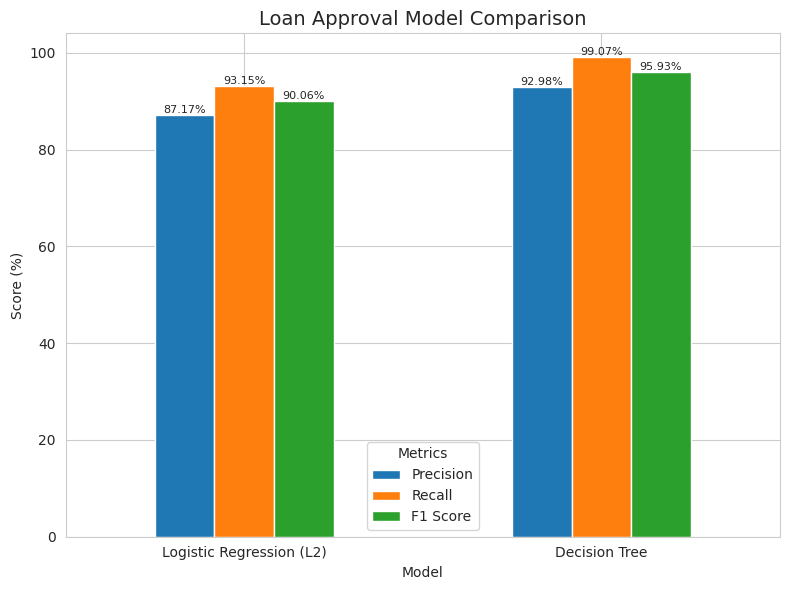

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score

def evaluate_model(name, y_test, y_pred, y_prob):

    acc = accuracy_score(y_test, y_pred) * 100
    roc = roc_auc_score(y_test, y_prob) * 100
    prec = precision_score(y_test, y_pred) * 100
    rec = recall_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred) * 100
    f2 = fbeta_score(y_test, y_pred, beta=2) * 100

    return [
        name,
        round(acc, 2),
        round(roc, 2),
        round(prec, 2),
        round(rec, 2),
        round(f1, 2),
        round(f2, 2)
    ]

# Generate Prediction & Probability
y_prob_lr = lr_model.predict_proba(X_test_processed)[:, 1]
y_prob_dt = dt_model.predict_proba(X_test_processed)[:, 1]

# Model Result
result_list = []

result_list.append(evaluate_model('Logistic Regression (L2)', y_test, y_pred_lr, y_prob_lr))
result_list.append(evaluate_model('Decision Tree', y_test, y_pred_dt, y_prob_dt))

result_data = pd.DataFrame(
    result_list,
    columns=['Model', 'Accuracy', 'ROC AUC', 'Precision', 'Recall', 'F1 Score', 'F2 Score']
)

result_dara = result_data.sort_values(['Recall', 'F1 Score'], ascending=False)
print(result_data)

# Visualization
ax = result_data.set_index('Model')[['Precision', 'Recall', 'F1 Score']].plot(kind='bar', figsize=(8,6))

plt.title('Loan Approval Model Comparison', fontsize=14)
plt.ylabel('Score (%)')
plt.xticks(rotation=0)
plt.legend(title='Metrics')

for container in ax.containers:
  ax.bar_label(
      container,
      fmt='%.2f%%',
      label_type='edge',
      fontsize=8
  )

plt.tight_layout()
plt.show()

The Decision Tree model significantly outperforms Logistic Regression, particularly in recall, achieving 99.07%. This ensures minimal rejection of eligible applicants while maintaining strong precision. However, further analysis reveals that performance is primarily driven by strong credit score separability in the dataset.

## ROC Curve Decision Tree

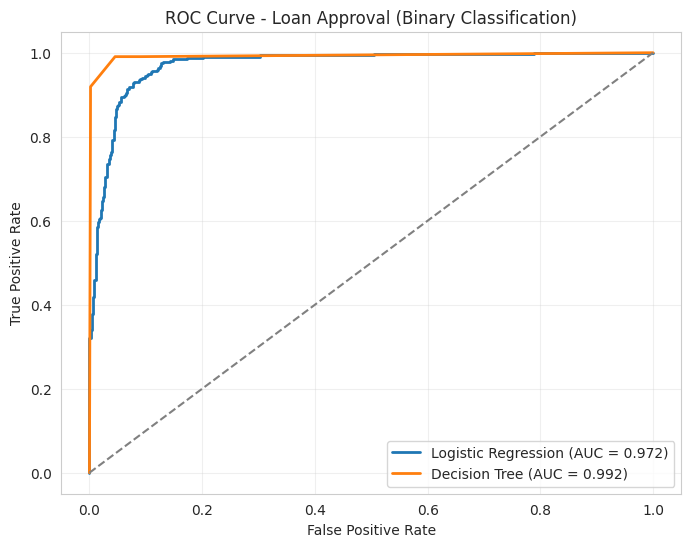

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability class 1 (Approved)
y_prob_lr = lr_model.predict_proba(X_test_processed)[:, 1]
y_prob_dt = dt_model.predict_proba(X_test_processed)[:, 1]

# Compute ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')

plt.plot([0,1],[0,1],'--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Loan Approval (Binary Classification)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
dt_model.classes_


array([0, 1])

# SHAP

In [ ]:
# Install SHAP
!pip install shap

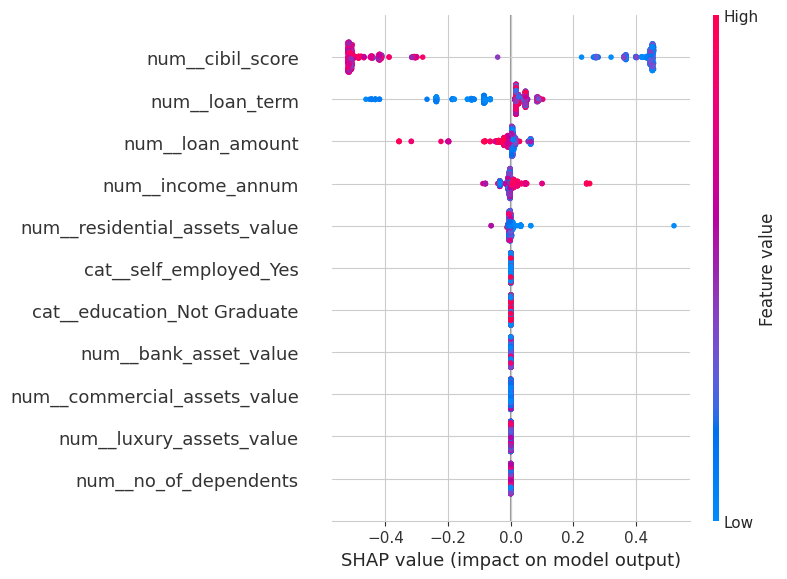

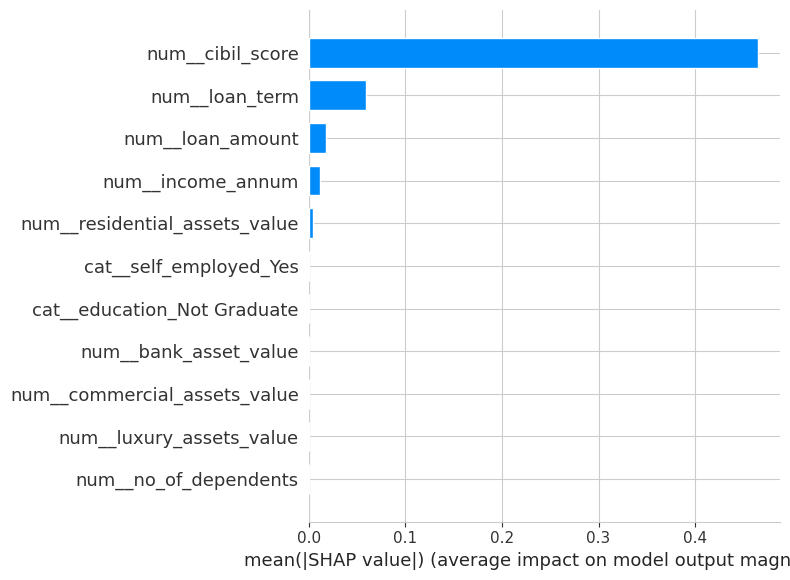

In [ ]:
import shap

# Initialize SHAP
explainer = shap.TreeExplainer(dt_model)
shap_values = explainer.shap_values(X_test_processed)
shap_class1 = shap_values[:, :, 1]

# Global feature importance
shap.summary_plot(
    shap_class1,
    X_test_processed,
    feature_names=preprocessor.get_feature_names_out(),
)

# SHAP Bar Plot
shap.summary_plot(
    shap_class1,
    X_test_processed,
    feature_names=preprocessor.get_feature_names_out(),
    plot_type="bar"
)

# Explain single prediction
shap.initjs()
shap.force_plot(
    explainer.expected_value[1],
    shap_class1[0],
    X_test_processed[0],
    feature_names=preprocessor.get_feature_names_out()
)

SHAP analysis reveals that CIBIL score overwhelmingly drives the model’s prediction. While the model achieves excellent performance metrics, it indicates a heavy dependency on a single feature. This suggests strong class separability based on credit score but may pose robustness risks if credit score distributions shift in production.

In [ ]:
# Save Model & Scaler
import joblib

#joblib.dump(dt_model, "/content/drive/MyDrive/Data Enthusiast Project/Elevvo Internship - ML/LoanApprovalPrediction/dt_model.pkl")
#joblib.dump(preprocessor, "/content/drive/MyDrive/Data Enthusiast Project/Elevvo Internship - ML/LoanApprovalPrediction/preprocessor.pkl")
#print("Model dan scaler berhasil disimpan!")